In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
events = pd.read_csv("data/events.csv")
orders = pd.read_csv("data/orders.csv")
customers = pd.read_csv("data/customers.csv")

events.head()

,user_id,event_type,product_id,timestamp
0,1004,view,105,2024-03-02 02:49:00
1,3084,view,151,2024-02-10 08:30:00
2,2590,view,183,2024-01-28 09:06:00
3,4311,view,184,2024-01-30 01:51:00
4,2242,view,120,2024-03-06 01:24:00


In [2]:
import sqlite3

conn = sqlite3.connect("ecommerce.db")

In [3]:
events.to_sql("events", conn, index=False, if_exists="replace")
orders.to_sql("orders", conn, index=False, if_exists="replace")
customers.to_sql("customers", conn, index=False, if_exists="replace")

10000

In [4]:
query = """
SELECT 
    COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_id END) AS views,
    COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_id END) AS carts,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) AS purchases
FROM events;
"""

import pandas as pd
result = pd.read_sql(query, conn)
result

,views,carts,purchases
0,9994,9520,8336


In [6]:
views=9994
carts=9520
purchases=8336
carts_rate=carts/views
purchases_rate=purchases/carts
print("carts_rate",round(carts_rate,2))
print("purchases_rate",round(purchases_rate,2))

carts_rate 0.95
purchases_rate 0.88


In [ ]:
"""
Business Insight:

The funnel shows a very high conversion from view to cart (~95%), indicating strong product interest and effective user engagement.

However, there is a drop of ~12% from cart to purchase, highlighting a potential revenue leakage point during the checkout stage.

This suggests possible friction such as pricing concerns, payment issues, or user experience barriers that may be impacting final conversions.
"""

In [10]:
query="""
Select
    customer_id,
    count(order_id) as Total_orders
from orders
group by customer_id;
"""
df_orders=pd.read_sql(query,conn)
df_orders


,customer_id,Total_orders
0,1,1
1,2,3
2,5,2
3,7,3
4,8,4
...,...,...
8331,9996,1
8332,9997,5
8333,9998,1
8334,9999,1


In [13]:
df_orders['customer_type']=df_orders['Total_orders'].apply(lambda x: "Repeat" if x>1 else "New")
df_orders['customer_type'].value_counts()

customer_type
Repeat    5483
New       2853
Name: count, dtype: int64

In [ ]:
"""
Business Insight:

A significant portion of customers (~66%) are repeat buyers, indicating strong customer retention and satisfaction.

This suggests that existing customers contribute heavily to revenue, making retention strategies a key driver of business growth.

Focusing on retaining high-value customers can further improve revenue stability and long-term profitability.
"""

In [16]:
query="""
select 
    customer_id,
    sum(revenue) as Total_revenue
from orders
group by customer_id;
"""
df_revenue=pd.read_sql(query,conn)
df_final=df_orders.merge(df_revenue,on='customer_id')
df_final.groupby('customer_type')['Total_revenue'].sum()

customer_type
New        3124698
Repeat    16892832
Name: Total_revenue, dtype: int64

In [ ]:
"""
Business Insight:

Repeat customers contribute significantly higher revenue compared to new customers, generating nearly 5 times more revenue.

This indicates that the business heavily relies on returning customers for revenue growth and stability.

Focusing on customer retention strategies, loyalty programs, and personalized experiences can further enhance revenue.
"""

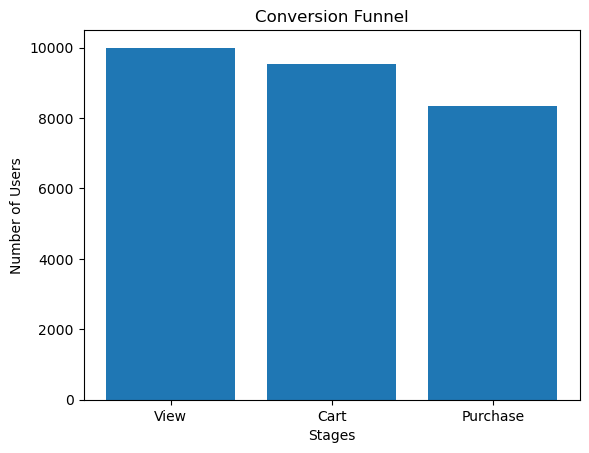

In [19]:
stages = ['View', 'Cart', 'Purchase']
values = [9994, 9520, 8336]

plt.figure()
plt.bar(stages, values)

plt.title("Conversion Funnel")
plt.xlabel("Stages")
plt.ylabel("Number of Users")

plt.show()

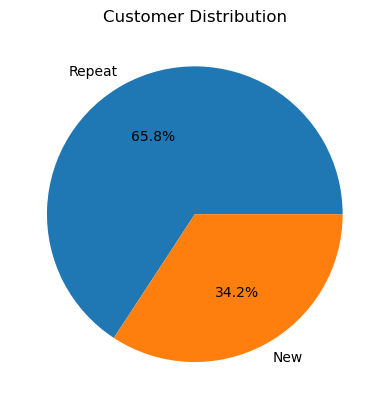

In [20]:
labels = ['Repeat', 'New']
values = [5483, 2853]

plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Customer Distribution")

plt.show()

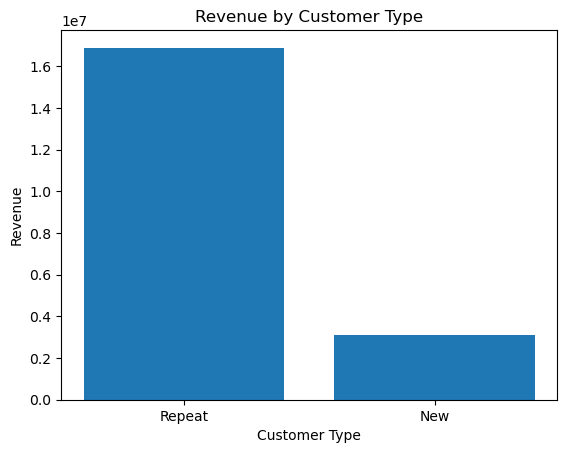

In [21]:
labels = ['Repeat', 'New']
values = [16892832, 3124698]

plt.figure()
plt.bar(labels, values)

plt.title("Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Revenue")

plt.show()